# Publication figures — finetune integration (ablations)

Loads finetune trial results, groups by **trial name** (all parameters except seed), and plots mean ± SEM across seeds.

**Ablation figures** — one figure per **task** (`TASKS_TO_PLOT`: Passive, Active, Pooled):
- **Subplots** = neural conditions (Baseline-PER, Prioritization, Reward Augmentation, …)
- **Lines** = ablation level at fixed baseline values for the other hyperparameters:
  - **Finetune threshold** (`ft`) at noise=0, β=1
  - **Model noise** at β=1; `ft` set via `NOISE_BETA_ABLATION_FT` / `plot_ablation_for_each_task(..., ft=...)`
  - **Neural β** at noise=0; same `ft` control

**Summary** — optional figure with best curve per task × condition, selected by:
- **Reward** — highest returns (blend of peak and terminal performance)
- **Speed** — high reward reached in fewer evaluation checkpoints


In [28]:
import ast
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TASKS_TO_PLOT = ["Passive", "Active", "Pooled"]



In [29]:
DATA_FILE = "trial_results_finetuning-2.csv"
SEED_COLUMN = "parameters_experiment_random_state"
# "results_success_rate" or "results_total_reward" (reward is mean return per eval checkpoint)
METRIC = "results_success_rate" 
METRIC_LABELS = {
    "results_success_rate": "Evaluation success rate",
    "results_total_reward": "Mean evaluation return",
    "results_steps": "Steps at evaluation",
}
METRIC_LABEL = METRIC_LABELS[METRIC]
WINDOW_SIZE =  5
FINAL_WINDOW = 5
# Best-curve selection: reward (high y) + speed (fewer checkpoints to strong return)
CURVE_PEAK_WEIGHT = 0.8       # reward = blend of peak and terminal return
CURVE_REWARD_WEIGHT = 0.3     # weight on reward vs speed when picking best curve
CURVE_SPEED_WEIGHT = 0.8
SPEED_REACH_MARGIN = 0.5      # shared target = best peak in group minus this (reward points)

CONDITION_COLUMN = "parameters_experiment_condition"
TASK_COLUMN = "parameters_experiment_task"
NOISE_COLUMN = "parameters_mlp_model_noise"
BETA_COLUMN = "parameters_neural_beta"
FT_COLUMN = "parameters_experiment_finetune_threshold"

ABLATION_NOISE_BASELINE_BETA = 1.0
ABLATION_NOISE_BASELINE_FT = 0.0
ABLATION_BETA_BASELINE_NOISE = 0.0
ABLATION_BETA_BASELINE_FT = 0.0
NOISE_BETA_ABLATION_FT = 0.0  # ft held fixed in noise/β ablation figures
ABLATION_FT_BASELINE_NOISE = 0.0
ABLATION_FT_BASELINE_BETA = 1.0
ABLATION_CONDITION = "Baseline-PER"

CONDITION_ORDER = [
    "Baseline-PER", "Prioritization-PER", "Q-Augmentation-PER",
    "Reward Augmentation-PER", "All-PER",
]
TASK_ORDER = ["Passive", "Active", "Pooled"]
NOISE_ORDER = [0.0, 0.1, 0.5, 1.0]
BETA_ORDER = [0.5, 1.0, 5.0, 10.0]
FT_ORDER = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUMERIC_ABLATION_COLS = ("noise", "beta", "ft")
# Use tasks present in the CSV when AUTO_TASKS_FROM_DATA is True
AUTO_TASKS_FROM_DATA = True

SAVE_FIGURES = False
FIGURES_DIR = Path("figures_publication")


In [30]:
def resolve_data_path(filename: str) -> Path:
    here = Path.cwd()
    search_dirs = [here, here / "src" / "results"]
    for parent in [here, *here.parents]:
        candidate = parent / "src" / "results"
        if candidate.is_dir() and candidate not in search_dirs:
            search_dirs.append(candidate)
    for d in search_dirs:
        path = d / filename
        if path.is_file():
            return path
    raise FileNotFoundError(f"Could not find {filename}")


def read_results_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except pd.errors.ParserError:
        return pd.read_csv(path, engine="python", on_bad_lines="skip")


PATH = resolve_data_path(DATA_FILE)
raw = read_results_csv(PATH)
print(f"Loaded {len(raw)} rows from {PATH}")


Loaded 307 rows from /Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/trial_results_finetuning-2.csv


In [31]:
def make_trial_name(row: pd.Series) -> str:
    return (
        f"{row['parameters_experiment_domain']}__{row['parameters_experiment_task']}__"
        f"{row['parameters_experiment_condition']}__{row['parameters_experiment_integration_type']}__"
        f"{row['parameters_experiment_model_granularity']}__"
        f"noise{row[NOISE_COLUMN]}__beta{row[BETA_COLUMN]}__ft{row[FT_COLUMN]}"
    )


def parse_series(value) -> np.ndarray:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.array([], dtype=float)
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
        except (SyntaxError, ValueError):
            return np.array([], dtype=float)
        return np.asarray(parsed, dtype=float)
    return np.asarray(value, dtype=float)


def parse_metric_series(row: pd.Series, metric_col: str) -> np.ndarray:
    arr = parse_series(row[metric_col])
    if metric_col != "results_total_reward" or len(arr) == 0:
        return arr

    # Training does all_total_rewards.extend(eval_reward) → 10 returns per eval,
    # while success_rate has one entry per eval. Align by chunking.
    if "results_success_rate" in row.index:
        n_checkpoints = len(parse_series(row["results_success_rate"]))
    else:
        n_checkpoints = 0

    if n_checkpoints > 0 and len(arr) % n_checkpoints == 0:
        chunk = len(arr) // n_checkpoints
        return np.nanmean(arr.reshape(n_checkpoints, chunk), axis=1)

    # Fallback (pretrain offline eval uses 10 episodes)
    chunk = 10
    n_checkpoints = len(arr) // chunk
    if n_checkpoints == 0:
        return arr
    return np.nanmean(arr[: n_checkpoints * chunk].reshape(n_checkpoints, chunk), axis=1)


def moving_average(arr: np.ndarray, window: int) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    if window <= 1 or len(arr) < window:
        return arr
    csum = np.cumsum(np.nan_to_num(arr), dtype=float)
    csum[window:] = csum[window:] - csum[:-window]
    return csum[window - 1:] / window


def aggregate_seed_rows(rows: pd.DataFrame, metric_col: str, window: int):
    series = [
        moving_average(parse_metric_series(row, metric_col), window)
        for _, row in rows.iterrows()
    ]
    series = [s for s in series if len(s)]
    if not series:
        return np.array([]), np.array([]), 0
    max_len = max(len(s) for s in series)
    padded = [np.pad(s, (0, max_len - len(s)), constant_values=np.nan) for s in series]
    stacked = np.vstack(padded)
    n = stacked.shape[0]
    sem = np.nanstd(stacked, axis=0) / np.sqrt(n) if n > 0 else np.nanstd(stacked, axis=0)
    return np.nanmean(stacked, axis=0), sem, n


def sort_named(values, order: list):
    rank = {v: i for i, v in enumerate(order)}
    return sorted(values, key=lambda v: (rank.get(v, 999), str(v)))


def final_score(mean_curve: np.ndarray, tail: int = FINAL_WINDOW) -> float:
    if len(mean_curve) == 0:
        return np.nan
    k = min(tail, len(mean_curve))
    return float(np.nanmean(mean_curve[-k:]))


def peak_reward(mean_curve: np.ndarray) -> float:
    if len(mean_curve) == 0:
        return np.nan
    return float(np.nanmax(mean_curve))


def reward_score(mean_curve: np.ndarray, tail: int = FINAL_WINDOW) -> float:
    """Highest returns: blend of peak and terminal performance."""
    peak = peak_reward(mean_curve)
    terminal = final_score(mean_curve, tail)
    if not np.isfinite(peak):
        return terminal
    if not np.isfinite(terminal):
        return peak
    return float(CURVE_PEAK_WEIGHT * peak + (1.0 - CURVE_PEAK_WEIGHT) * terminal)


def _normalize_series(values: pd.Series) -> pd.Series:
    lo, hi = values.min(), values.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(1.0, index=values.index)
    return (values - lo) / (hi - lo)


def steps_to_reach(mean_curve: np.ndarray, threshold: float) -> int:
    """Absolute evaluation-checkpoint index when the curve first reaches ``threshold``."""
    y = np.asarray(mean_curve, dtype=float)
    if len(y) == 0:
        return 0
    hit = np.where(y >= threshold)[0]
    return int(hit[0]) if len(hit) else len(y)


def add_curve_scores(grp: pd.DataFrame) -> pd.DataFrame:
    """Score curves within a task × condition group.

  Speed uses the same reward target for every trial in the group (best peak − margin)
  and counts absolute checkpoints to reach it — run length does not inflate the score.
    """
    out = grp.copy()
    group_peak = float(out["peak_reward"].max())
    threshold = group_peak - SPEED_REACH_MARGIN
    out["reach_threshold"] = threshold
    out["steps_to_threshold"] = out["mean"].apply(lambda m: steps_to_reach(m, threshold))
    out["speed_score"] = out["peak_reward"] / (out["steps_to_threshold"] + 1)
    out["reward_norm"] = _normalize_series(out["reward_score"])
    out["speed_norm"] = _normalize_series(out["speed_score"])
    out["curve_score"] = (
        CURVE_REWARD_WEIGHT * out["reward_norm"] + CURVE_SPEED_WEIGHT * out["speed_norm"]
    )
    return out


raw["trial_name"] = raw.apply(make_trial_name, axis=1)
print(f"{raw['trial_name'].nunique()} unique trial names; "
      f"seeds/trial: {raw.groupby('trial_name')[SEED_COLUMN].nunique().median():.0f} median")

if AUTO_TASKS_FROM_DATA:
    present_tasks = sort_named(raw[TASK_COLUMN].dropna().unique().tolist(), TASK_ORDER)
    globals()["TASKS_TO_PLOT"] = present_tasks
    print(f"Tasks in data: {present_tasks}")


87 unique trial names; seeds/trial: 5 median
Tasks in data: ['Passive', 'Active', 'Pooled']


In [32]:
def build_aggregated_table(df: pd.DataFrame, metric_col: str = METRIC) -> pd.DataFrame:
    records = []
    for trial_name, grp in df.groupby("trial_name", sort=False):
        mean, sem, n_seeds = aggregate_seed_rows(grp, metric_col, WINDOW_SIZE)
        rep = grp.iloc[0]
        records.append({
            "trial_name": trial_name,
            "mean": mean,
            "sem": sem,
            "n_seeds": n_seeds,
            "task": rep[TASK_COLUMN],
            "condition": rep[CONDITION_COLUMN],
            "noise": float(rep[NOISE_COLUMN]),
            "beta": float(rep[BETA_COLUMN]),
            "ft": float(rep[FT_COLUMN]),
            "peak_reward": peak_reward(mean),
            "final_score": final_score(mean),
            "reward_score": reward_score(mean),
        })
    return pd.DataFrame(records)


agg = build_aggregated_table(raw)
agg.head()


,trial_name,mean,sem,n_seeds,task,condition,noise,beta,ft,peak_reward,final_score,reward_score
0,Robot__Passive__Baseline-PER__finetune__binary...,"[0.032, 0.032, 0.032, 0.032, 0.031999999999999...","[0.013386560424545207, 0.013386560424545207, 0...",5,Passive,Baseline-PER,0.0,0.5,0.0,1.000000,0.979840,0.995968
1,Robot__Passive__Baseline-PER__finetune__binary...,"[0.028571428571428574, 0.028571428571428574, 0...","[0.01058080114025773, 0.01058080114025773, 0.0...",7,Passive,Baseline-PER,0.0,1.0,0.0,1.000000,0.980800,0.996160
2,Robot__Passive__Baseline-PER__finetune__binary...,"[0.032, 0.032, 0.032, 0.032, 0.031999999999999...","[0.013386560424545207, 0.013386560424545207, 0...",5,Passive,Baseline-PER,0.0,5.0,0.0,1.000000,0.988160,0.997632
3,Robot__Active__Baseline-PER__finetune__binary_...,"[0.032, 0.032, 0.032, 0.032, 0.031999999999999...","[0.013386560424545207, 0.013386560424545207, 0...",5,Active,Baseline-PER,0.0,0.5,0.0,0.998400,0.994560,0.997632
4,Robot__Active__Baseline-PER__finetune__binary_...,"[0.028571428571428574, 0.028571428571428574, 0...","[0.01058080114025773, 0.01058080114025773, 0.0...",7,Active,Baseline-PER,0.0,1.0,0.0,0.997714,0.994971,0.997166


In [33]:
def select_best_rows_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> pd.DataFrame:
    """Return agg rows with the best curve_score per task × condition."""
    sub = table.copy()
    if filters:
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

    picks = []
    for (_, _), grp in sub.groupby(["task", "condition"], sort=False):
        if grp.empty:
            continue
        scored = add_curve_scores(grp)
        valid = scored[scored["curve_score"].notna()]
        picks.append(valid.loc[valid["curve_score"].idxmax()] if not valid.empty else scored.iloc[0])
    if not picks:
        return pd.DataFrame()
    return pd.DataFrame(picks).reset_index(drop=True)


def select_best_ablations_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> pd.DataFrame:
    """Summary table of best (noise, beta, ft) per task × condition."""
    best_rows = select_best_rows_per_task_condition(table, filters=filters)
    if best_rows.empty:
        return best_rows
    return (
        best_rows.assign(
            best_noise=best_rows["noise"],
            best_beta=best_rows["beta"],
            best_ft=best_rows["ft"],
        )[
            [
                "task",
                "condition",
                "best_noise",
                "best_beta",
                "best_ft",
                "curve_score",
                "steps_to_threshold",
                "reach_threshold",
                "reward_score",
                "speed_score",
                "peak_reward",
                "final_score",
                "n_seeds",
                "trial_name",
            ]
        ]
        .sort_values(["task", "condition"])
        .reset_index(drop=True)
    )


FT_BEST_FILTERS = {
    "noise": ABLATION_FT_BASELINE_NOISE,
    "beta": ABLATION_FT_BASELINE_BETA,
}

best_ablations = select_best_ablations_per_task_condition(agg, filters=FT_BEST_FILTERS)
print("Best ablation per task × condition (ft sweep at noise=0, β=1):")
best_ablations


Best ablation per task × condition (ft sweep at noise=0, β=1):


,task,condition,best_noise,best_beta,best_ft,curve_score,steps_to_threshold,reach_threshold,reward_score,speed_score,peak_reward,final_score,n_seeds,trial_name
0,Active,All-PER,0.0,1.0,0.0,1.100000,99,0.500000,0.999744,0.010000,1.000000,0.998720,5,Robot__Active__All-PER__finetune__binary__nois...
1,Active,Baseline-PER,0.0,1.0,0.0,1.100000,165,0.497714,0.997166,0.006010,0.997714,0.994971,7,Robot__Active__Baseline-PER__finetune__binary_...
2,Active,Prioritization-PER,0.0,1.0,0.0,1.100000,141,0.500000,0.999269,0.007042,1.000000,0.996343,7,Robot__Active__Prioritization-PER__finetune__b...
3,Active,Q-Augmentation-PER,0.0,1.0,0.0,1.100000,87,0.500000,0.999314,0.011364,1.000000,0.996571,7,Robot__Active__Q-Augmentation-PER__finetune__b...
4,Active,Reward Augmentation-PER,0.0,1.0,0.0,1.100000,173,0.496000,0.994987,0.005724,0.996000,0.990933,6,Robot__Active__Reward Augmentation-PER__finetu...
5,Passive,All-PER,0.0,1.0,0.0,1.098439,24,0.500000,0.998027,0.040000,1.000000,0.990133,6,Robot__Passive__All-PER__finetune__binary__noi...
6,Passive,Baseline-PER,0.0,1.0,0.0,1.096532,51,0.500000,0.996160,0.019231,1.000000,0.980800,7,Robot__Passive__Baseline-PER__finetune__binary...
7,Passive,Prioritization-PER,0.0,1.0,0.0,1.095584,39,0.500000,0.996800,0.025000,1.000000,0.984000,7,Robot__Passive__Prioritization-PER__finetune__...
8,Passive,Q-Augmentation-PER,0.0,1.0,0.0,1.098953,26,0.500000,0.999040,0.037037,1.000000,0.995200,6,Robot__Passive__Q-Augmentation-PER__finetune__...
9,Passive,Reward Augmentation-PER,0.0,1.0,0.0,1.098589,50,0.500000,0.996640,0.019608,1.000000,0.983200,6,Robot__Passive__Reward Augmentation-PER__finet...


In [ ]:


def slice_plot_range(arr, start_idx=None, end_idx=None):
    """Slice a results series for plotting; None start/end = full array."""
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    start = 0 if start_idx is None else int(start_idx)
    end = n if end_idx is None else int(end_idx)
    start = max(0, min(start, n))
    end = max(start, min(end, n))
    return arr[start:end], start, end

def plot_mean_sem(ax, mean, sem, label, color, start_idx=None, end_idx=None):
    mean, start, end = slice_plot_range(mean, start_idx, end_idx)
    sem, _, _ = slice_plot_range(sem, start_idx, end_idx)
    if len(mean) == 0:
        return False
    x = np.arange(start, end)
    #ax.plot(x, mean, label=label, color=color, alpha=0.6)
    ax.plot(x, mean, label=label, color=color, zorder=3, marker='o', markevery=500, markersize=6, markeredgecolor='white', markeredgewidth=0.8)
    if np.any(np.isfinite(sem)) and np.nanmax(sem) > 0:
        ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2, linewidth=0)
    return True


def publication_figure(
    table: pd.DataFrame,
    *,
    title: str,
    line_col: str,
    line_values: list,
    line_labels: list | None = None,
    subplot_col: str = "task",
    subplot_values: list | None = None,
    filters: dict | None = None,
    filename: str | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    sub = table.copy()
    if filters:
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

    order = CONDITION_ORDER if subplot_col == "condition" else TASK_ORDER
    subplot_values = subplot_values or sort_named(sub[subplot_col].dropna().unique().tolist(), order)
    n = len(subplot_values)
    ncols = min(n, 2)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    match_line_to_subplot = line_col == subplot_col

    for i, subplot_val in enumerate(subplot_values):
        ax = axes[i]
        vals = [subplot_val] if match_line_to_subplot else line_values
        for j, line_val in enumerate(vals):
            if line_col in NUMERIC_ABLATION_COLS:
                mask = (sub[subplot_col] == subplot_val) & np.isclose(sub[line_col], line_val)
            else:
                mask = (sub[subplot_col] == subplot_val) & (sub[line_col] == line_val)
            row = sub[mask]
            if row.empty:
                continue
            r = row.iloc[0]
            label = (line_labels[j] if line_labels else str(line_val))
            label = f"{label} (n={int(r['n_seeds'])})"
            plot_mean_sem(ax, r["mean"], r["sem"], label, PALETTE[j % len(PALETTE)], start_idx=start_idx, end_idx=end_idx)

        ax.set_title(str(subplot_val))
        ax.set_xlabel("Evaluation checkpoint")
        if i % ncols == 0:
            ax.set_ylabel(METRIC_LABEL)
        ax.legend(frameon=False, loc="upper left")
        if METRIC == "results_success_rate":
            ax.set_ylim(bottom=-0.02, top=1.02)
        ax.grid(True, alpha=0.25, linewidth=0.6)

    for j in range(len(subplot_values), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()

    # if SAVE_FIGURES and filename:
    #     FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    #     stem = Path(filename).stem
    #     for ext in (".pdf", ".png"):
    #         out = FIGURES_DIR / f"{stem}{ext}"
    #         fig.savefig(out)
    #         print(f"Saved {out}")

    plt.show()
    return fig


PALETTE = list(plt.cm.tab10.colors)


def slugify(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_")


def tasks_to_plot() -> list:
    if TASKS_TO_PLOT is None:
        return list(TASK_ORDER)
    return [t for t in TASK_ORDER if t in TASKS_TO_PLOT]


def line_values_present(sub: pd.DataFrame, line_col: str, candidates: list) -> list:
    present = []
    for v in candidates:
        if line_col in NUMERIC_ABLATION_COLS:
            hit = sub[np.isclose(sub[line_col], v)]
        else:
            hit = sub[sub[line_col] == v]
        if not hit.empty:
            present.append(v)
    return present


def subplot_values_present(sub: pd.DataFrame, subplot_col: str, candidates: list) -> list:
    present = sort_named(sub[subplot_col].dropna().unique().tolist(), candidates)
    return present


def plot_ablation_for_each_task(
    table: pd.DataFrame,
    *,
    ablation_kind: str,
    min_lines: int = 2,
    ft: float | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    """One figure per task; subplots = neural conditions; lines = ablation values.

    For noise and beta sweeps, pass ``ft`` to hold finetune threshold fixed
    (defaults to ABLATION_NOISE_BASELINE_FT / ABLATION_BETA_BASELINE_FT).
    """
    if ablation_kind == "noise":
        ft_val = ABLATION_NOISE_BASELINE_FT if ft is None else float(ft)
        fixed = {
            "beta": ABLATION_NOISE_BASELINE_BETA,
            "ft": ft_val,
        }
        line_col, candidates = "noise", NOISE_ORDER
        line_labels = [f"noise = {v}" for v in NOISE_ORDER]
        prefix = "ablation_model_noise"
        fixed_title = f"β = {ABLATION_NOISE_BASELINE_BETA}, ft = {ft_val:g}"
    elif ablation_kind == "beta":
        ft_val = ABLATION_BETA_BASELINE_FT if ft is None else float(ft)
        fixed = {
            "noise": ABLATION_BETA_BASELINE_NOISE,
            "ft": ft_val,
        }
        line_col, candidates = "beta", BETA_ORDER
        line_labels = [f"β = {v}" for v in BETA_ORDER]
        prefix = "ablation_neural_beta"
        fixed_title = f"noise = {ABLATION_BETA_BASELINE_NOISE}, ft = {ft_val:g}"
    elif ablation_kind in ("ft", "ff"):
        fixed = {"noise": ABLATION_FT_BASELINE_NOISE, "beta": ABLATION_FT_BASELINE_BETA}
        line_col, candidates = "ft", FT_ORDER
        line_labels = [f"ft = {v:g}" for v in FT_ORDER]
        prefix = "ablation_finetune_threshold"
        fixed_title = f"noise = {ABLATION_FT_BASELINE_NOISE}, β = {ABLATION_FT_BASELINE_BETA}"
    else:
        raise ValueError("ablation_kind must be 'noise', 'beta', or 'ft'")

    for task in tasks_to_plot():
        filters = {"task": task, **fixed}
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        present = line_values_present(sub, line_col, candidates)
        if len(conditions) < 1 or len(present) < min_lines:
            print(f"Skip {task} ({ablation_kind}): {len(conditions)} conditions, {len(present)} ablation levels")
            continue

        present_labels = [line_labels[candidates.index(v)] for v in present]
        ablation_title = {
            "noise": "model noise",
            "beta": "neural β",
            "ft": "finetune threshold",
            "ff": "finetune threshold",
        }.get(ablation_kind, ablation_kind)
        if ablation_kind in ("noise", "beta"):
            fname = f"{prefix}__ft{fixed['ft']:g}__{slugify(task)}.pdf"
        else:
            fname = f"{prefix}__{slugify(task)}.pdf"
        publication_figure(
            table,
            title=f"{task} — {ablation_title} ablation ({fixed_title})",
            line_col=line_col,
            line_values=present,
            line_labels=present_labels,
            subplot_col="condition",
            subplot_values=conditions,
            filters=filters,
            filename=fname,
            start_idx=start_idx,
            end_idx=end_idx,
        )


def plot_finetune_threshold_ablation(
    table: pd.DataFrame,
    *,
    min_lines: int = 1,
    tasks: list | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    """One figure per task; subplots = neural conditions; lines = finetune_threshold.

    Fixed at noise=0 and β=1 (see ABLATION_FT_BASELINE_* in config cell).
    """
    task_list = tasks if tasks is not None else tasks_to_plot()
    for task in task_list:
        filters = {
            "task": task,
            "noise": ABLATION_FT_BASELINE_NOISE,
            "beta": ABLATION_FT_BASELINE_BETA,
        }
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        ft_present = line_values_present(sub, "ft", FT_ORDER)
        if not conditions:
            print(f"Skip {task}: no conditions at noise=0, β=1")
            continue
        if len(ft_present) < min_lines:
            print(f"Skip {task}: only {len(ft_present)} finetune_threshold level(s) present")
            continue

        ft_labels = [f"ft = {v:g}" for v in ft_present]
        publication_figure(
            table,
            title=(
                f"{task} — finetune threshold ablation "
                f"(noise = {ABLATION_FT_BASELINE_NOISE}, β = {ABLATION_FT_BASELINE_BETA})"
            ),
            line_col="ft",
            line_values=ft_present,
            line_labels=ft_labels,
            subplot_col="condition",
            subplot_values=conditions,
            filters=filters,
            filename=f"ablation_finetune_threshold__{slugify(task)}.pdf",
            start_idx=start_idx,
            end_idx=end_idx,
        )


def plot_conditions_best_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    """One figure: subplots = tasks; lines = conditions at each one's best (noise, β, ft)."""
    best_rows = select_best_rows_per_task_condition(table, filters=filters)
    if best_rows.empty:
        print("Skip: no rows for per-condition best-ablation chart")
        return None

    tasks = [t for t in tasks_to_plot() if t in best_rows["task"].values]
    if not tasks:
        print("Skip: no tasks for per-condition best-ablation chart")
        return None

    n = len(tasks)
    ncols = min(n, 2)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for i, task in enumerate(tasks):
        ax = axes[i]
        task_rows = best_rows[best_rows["task"] == task]
        task_rows = task_rows.assign(
            _order=task_rows["condition"].map({c: i for i, c in enumerate(CONDITION_ORDER)})
        ).sort_values(["_order", "condition"])

        for j, (_, r) in enumerate(task_rows.iterrows()):
            label = (
                f"{r['condition']}\n"
                f"ft={r['ft']:g}, peak={r['peak_reward']:.1f}, "
                f"score={r['curve_score']:.2f} (n={int(r['n_seeds'])})"
            )
            plot_mean_sem(ax, r["mean"], r["sem"], label, PALETTE[j % len(PALETTE)], start_idx=start_idx, end_idx=end_idx)

        ax.set_title(task)
        ax.set_xlabel("Evaluation checkpoint")
        if i % ncols == 0:
            ax.set_ylabel(METRIC_LABEL)
        ax.legend(frameon=False, loc="upper left", fontsize=8)
        if METRIC == "results_success_rate":
            ax.set_ylim(bottom=-0.02, top=1.02)
        ax.grid(True, alpha=0.25, linewidth=0.6)

    for j in range(len(tasks), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"Best curves per condition — reward + speed ({METRIC_LABEL})",
        fontsize=13,
        y=1.02,
    )
    fig.tight_layout()

    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        for ext in (".pdf", ".png"):
            out = FIGURES_DIR / f"conditions_best_per_task_condition{ext}"
            fig.savefig(out)
            print(f"Saved {out}")

    plt.show()
    return fig

def display_ablation_summaries(
    table: pd.DataFrame,
    *,
    ablation_col: str,
    ablation_order: list,
    fixed: dict,
    label: str,
):
    """Pivot tables of curve score / peak / terminal return per condition × ablation level."""
    sub = table.copy()
    for key, val in fixed.items():
        if key in NUMERIC_ABLATION_COLS:
            sub = sub[np.isclose(sub[key], val)]
        else:
            sub = sub[sub[key] == val]
    if sub.empty:
        print(f"Skip {label} summaries: no rows at fixed baseline")
        return

    scored = pd.concat(
        [add_curve_scores(grp) for (_, _), grp in sub.groupby(["task", "condition"], sort=False)],
        ignore_index=True,
    )
    curve_summary = (
        scored.pivot_table(index="condition", columns=ablation_col, values="curve_score", aggfunc="first")
        .reindex(index=CONDITION_ORDER, columns=ablation_order)
    )
    peak_summary = (
        scored.pivot_table(index="condition", columns=ablation_col, values="peak_reward", aggfunc="first")
        .reindex(index=CONDITION_ORDER, columns=ablation_order)
    )
    final_summary = (
        scored.pivot_table(index="condition", columns=ablation_col, values="final_score", aggfunc="first")
        .reindex(index=CONDITION_ORDER, columns=ablation_order)
    )

    fixed_bits = ", ".join(
        f"{k} = {v:g}" if k in NUMERIC_ABLATION_COLS else f"{k} = {v}"
        for k, v in fixed.items()
    )
    print(f"{label} — curve score per condition (fixed: {fixed_bits}):")
    display(curve_summary)
    print(f"Peak {METRIC_LABEL}:")
    display(peak_summary)
    print(f"Terminal {METRIC_LABEL} (last {FINAL_WINDOW} checkpoints):")
    display(final_summary)


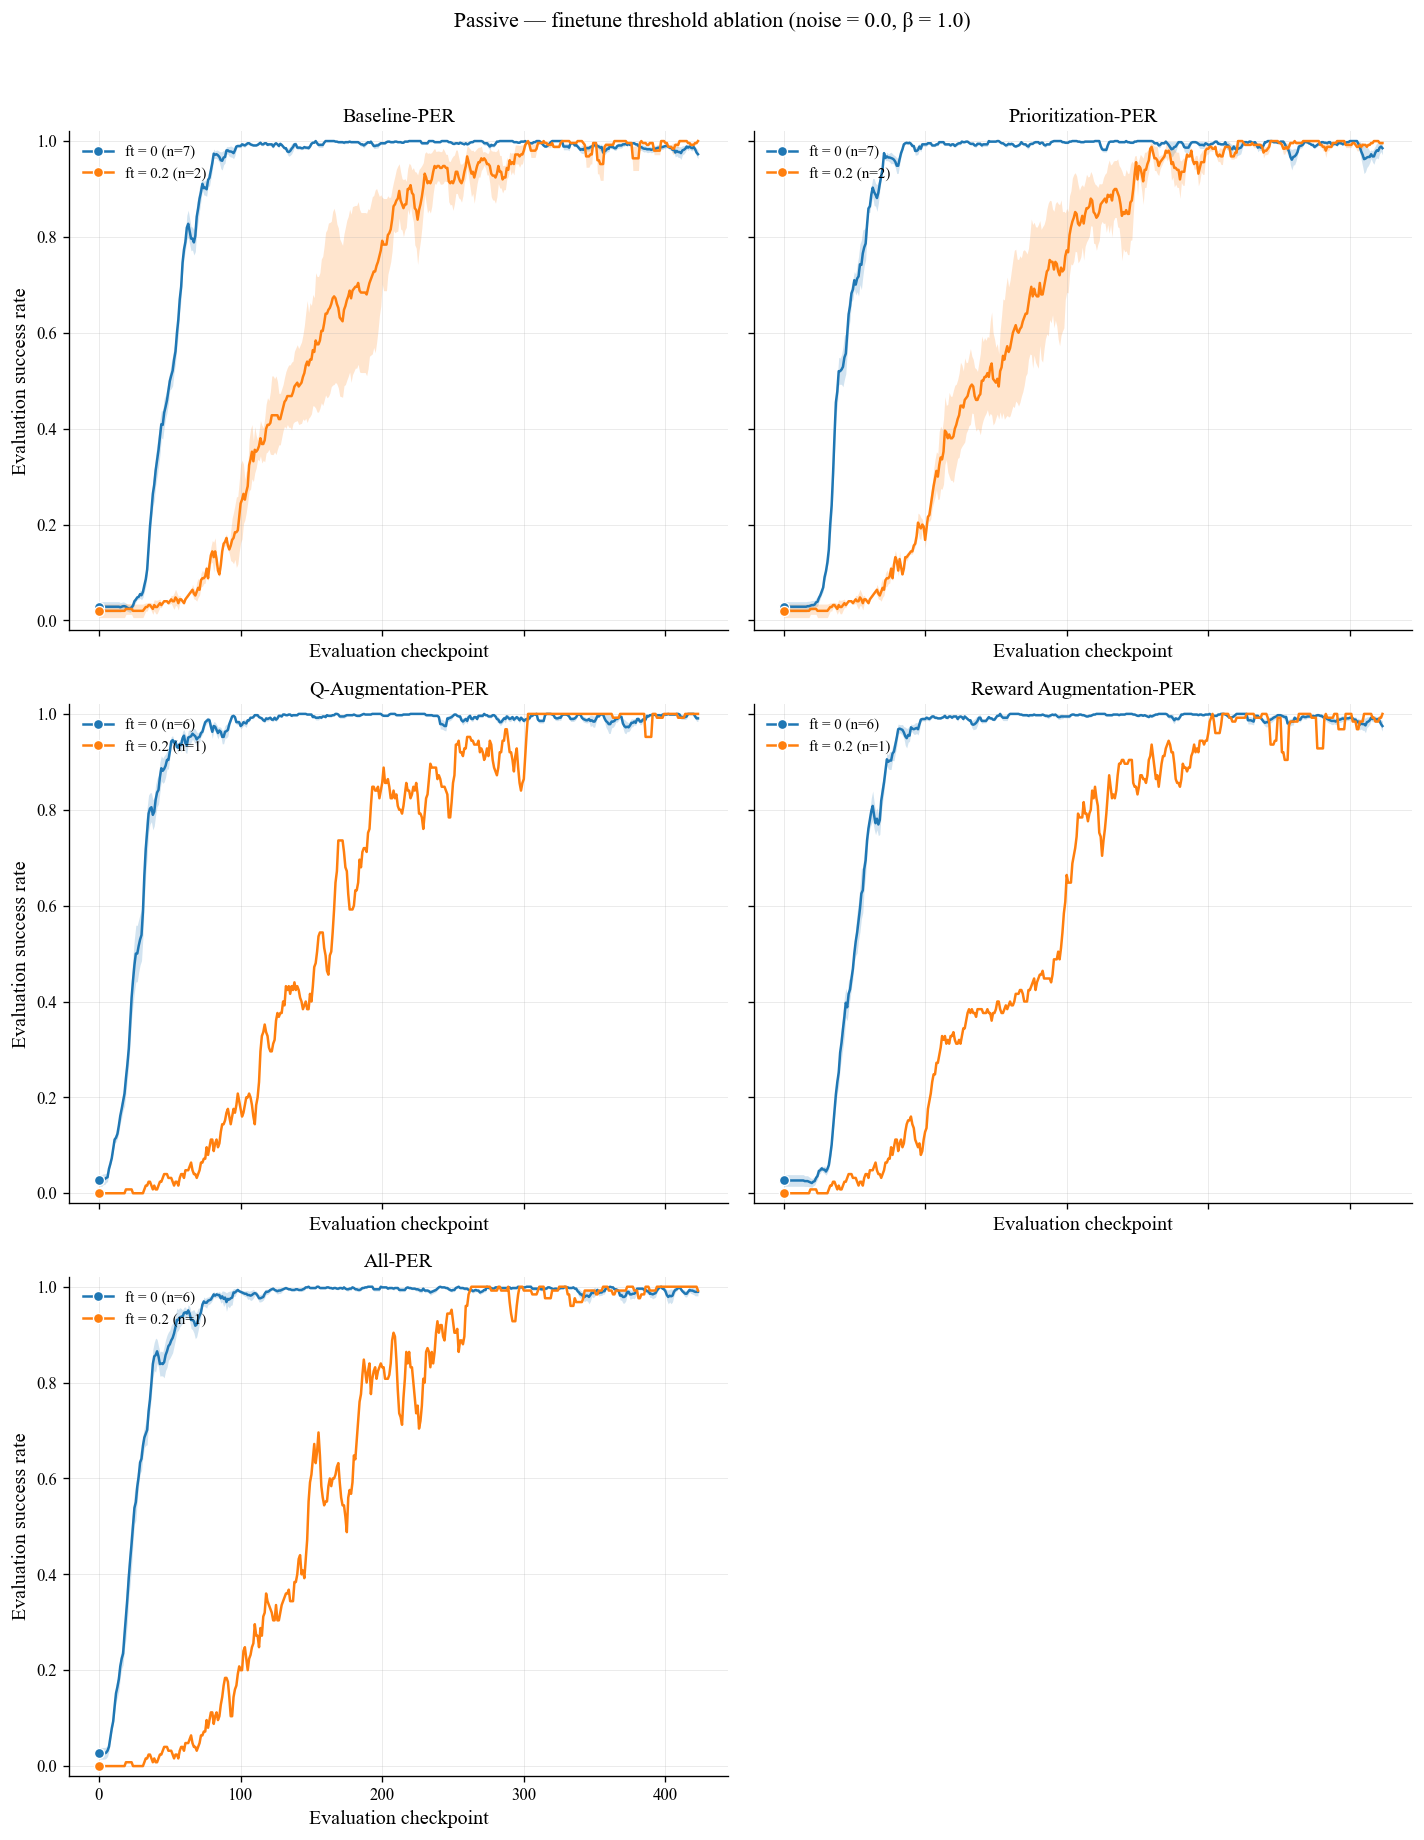

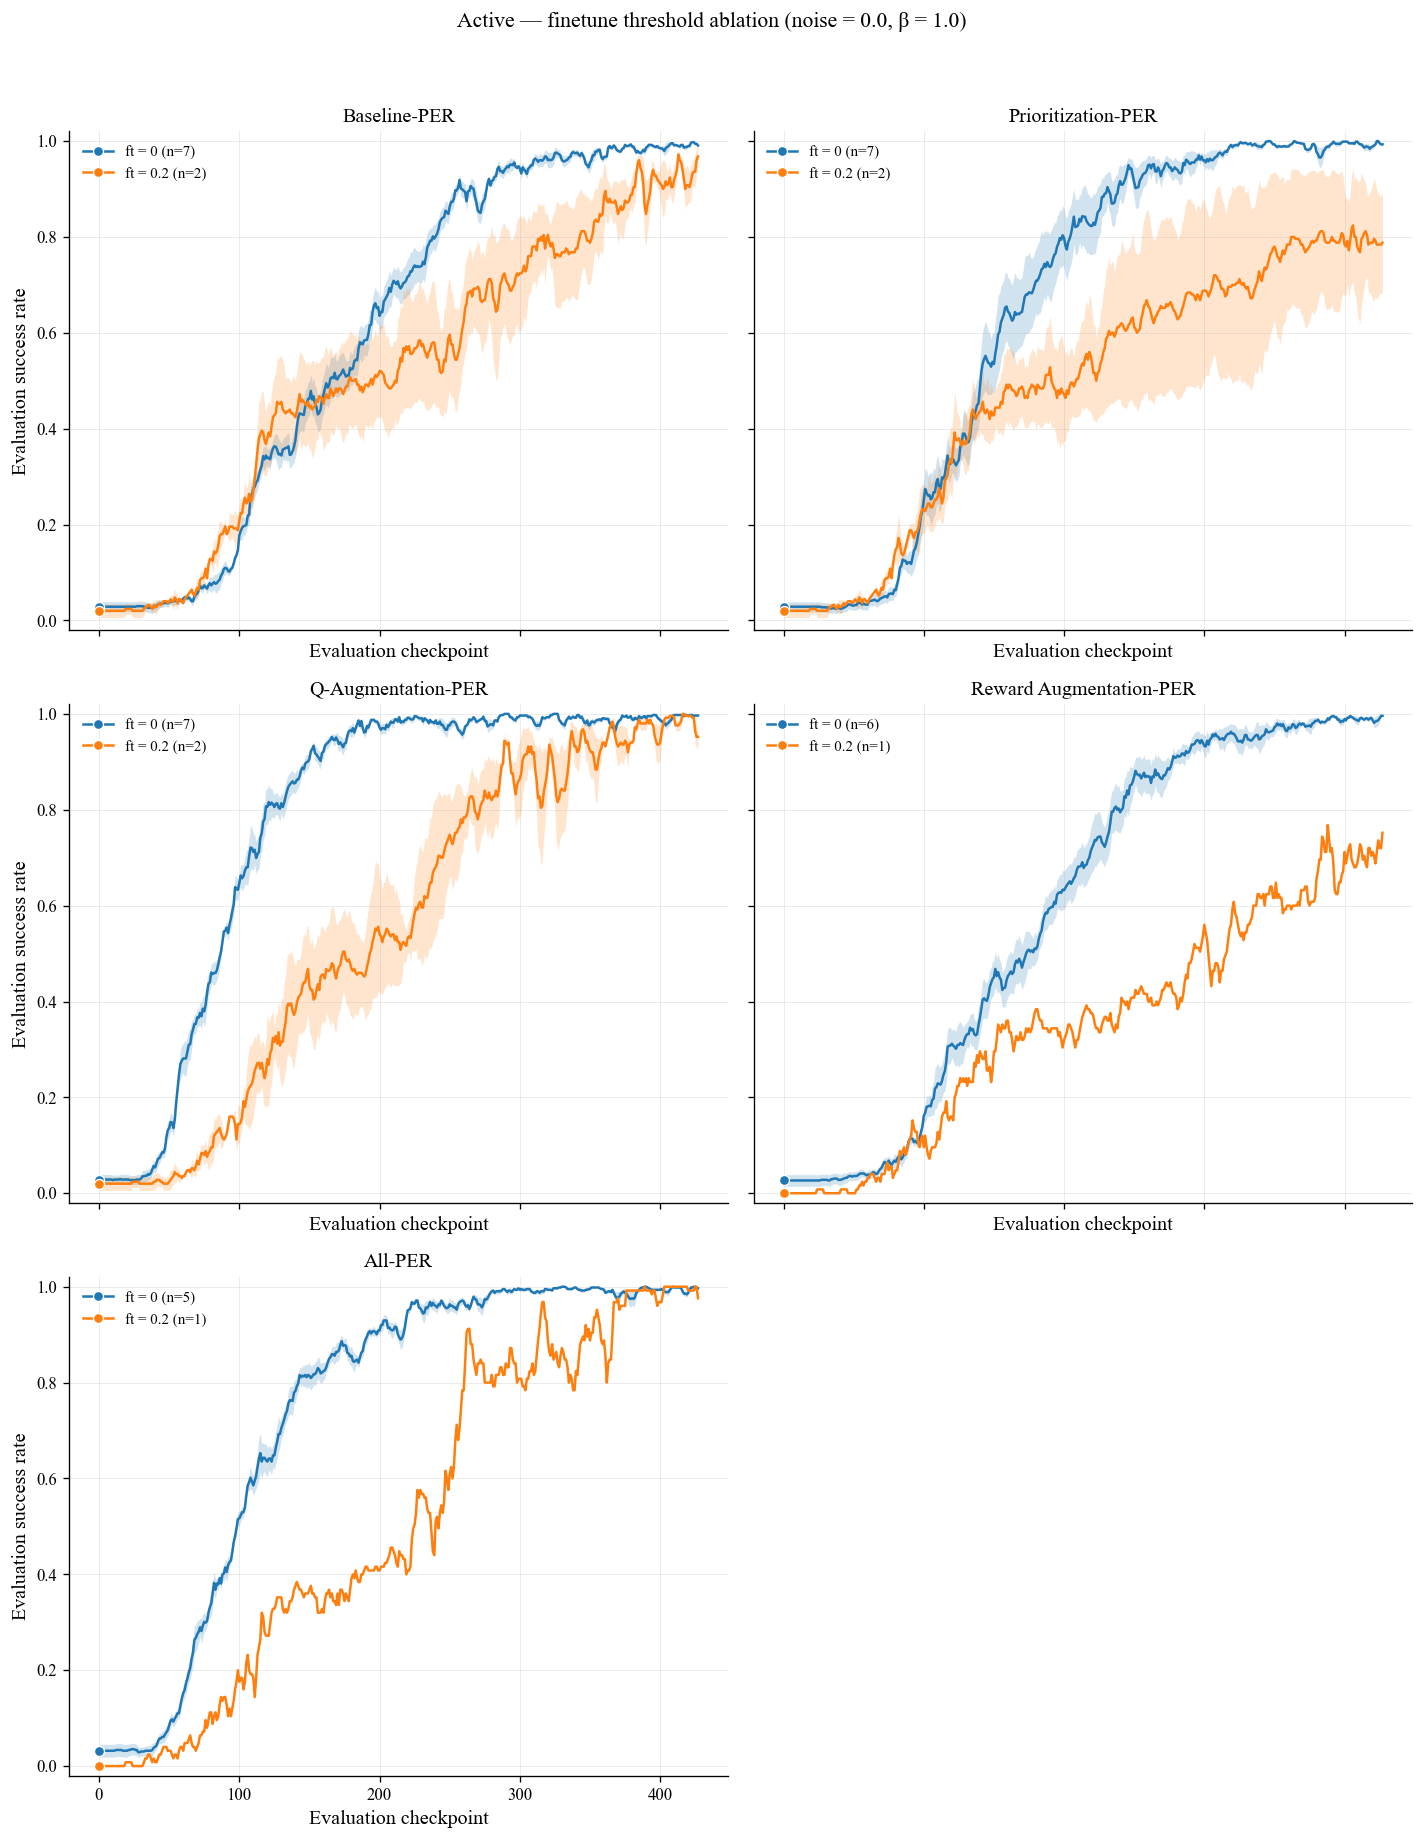

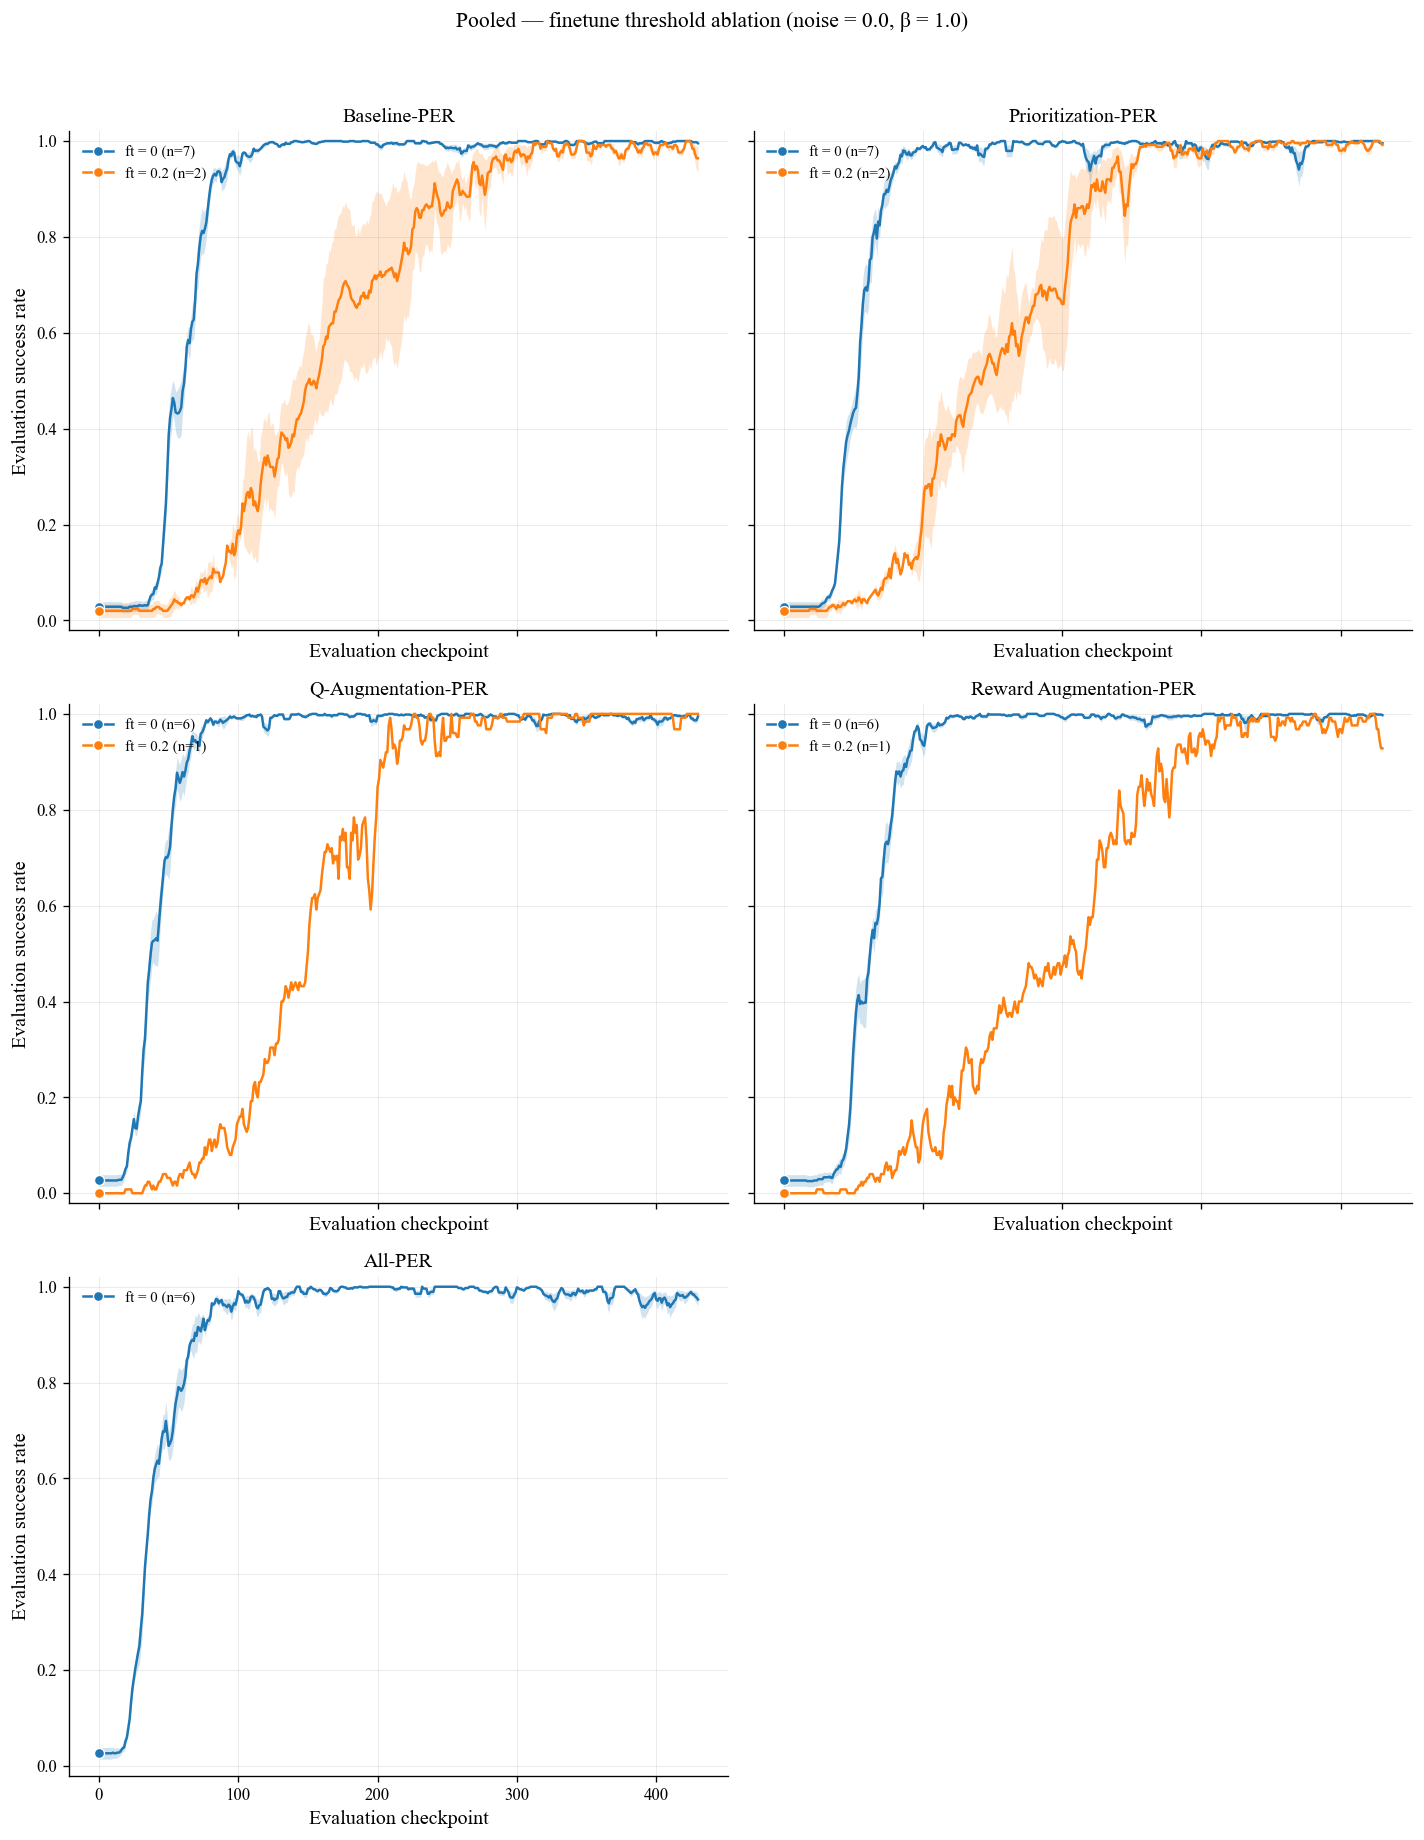

In [35]:
# --- Finetune-threshold ablation: one figure per task ---
# Subplots = neural conditions; lines = finetune_threshold (noise=0, β=1)
plot_finetune_threshold_ablation(agg, min_lines=1)


In [36]:
# --- Model-noise ablation: one figure per task ---
# Subplots = neural conditions; lines = model noise (β=1, ft=NOISE_BETA_ABLATION_FT)
plot_ablation_for_each_task(
    agg,
    ablation_kind="noise",
    min_lines=1,
    ft=0.4,
)


Skip Passive (noise): 0 conditions, 0 ablation levels
Skip Active (noise): 0 conditions, 0 ablation levels
Skip Pooled (noise): 0 conditions, 0 ablation levels


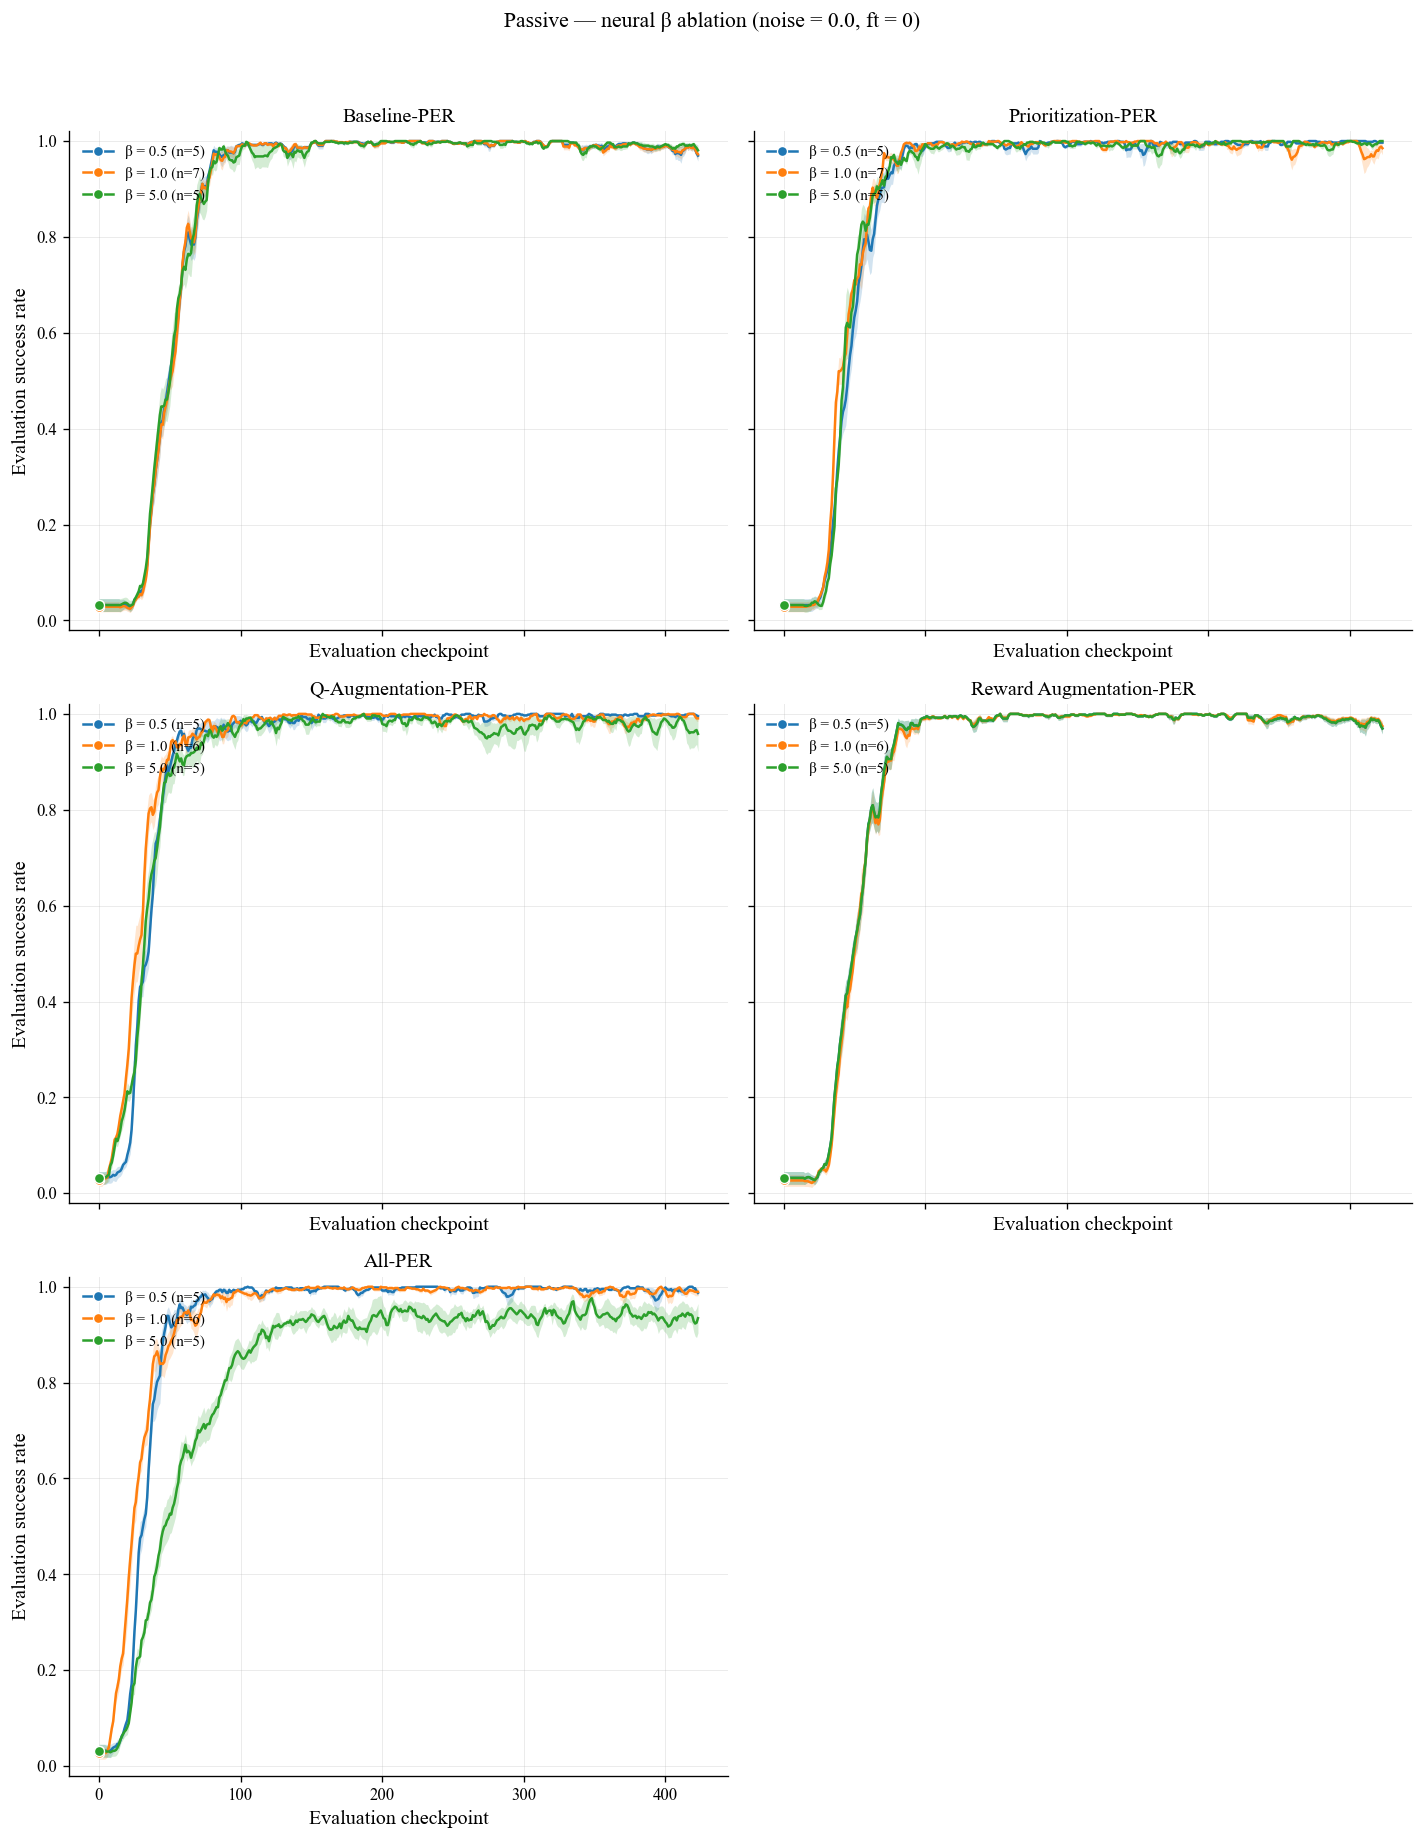

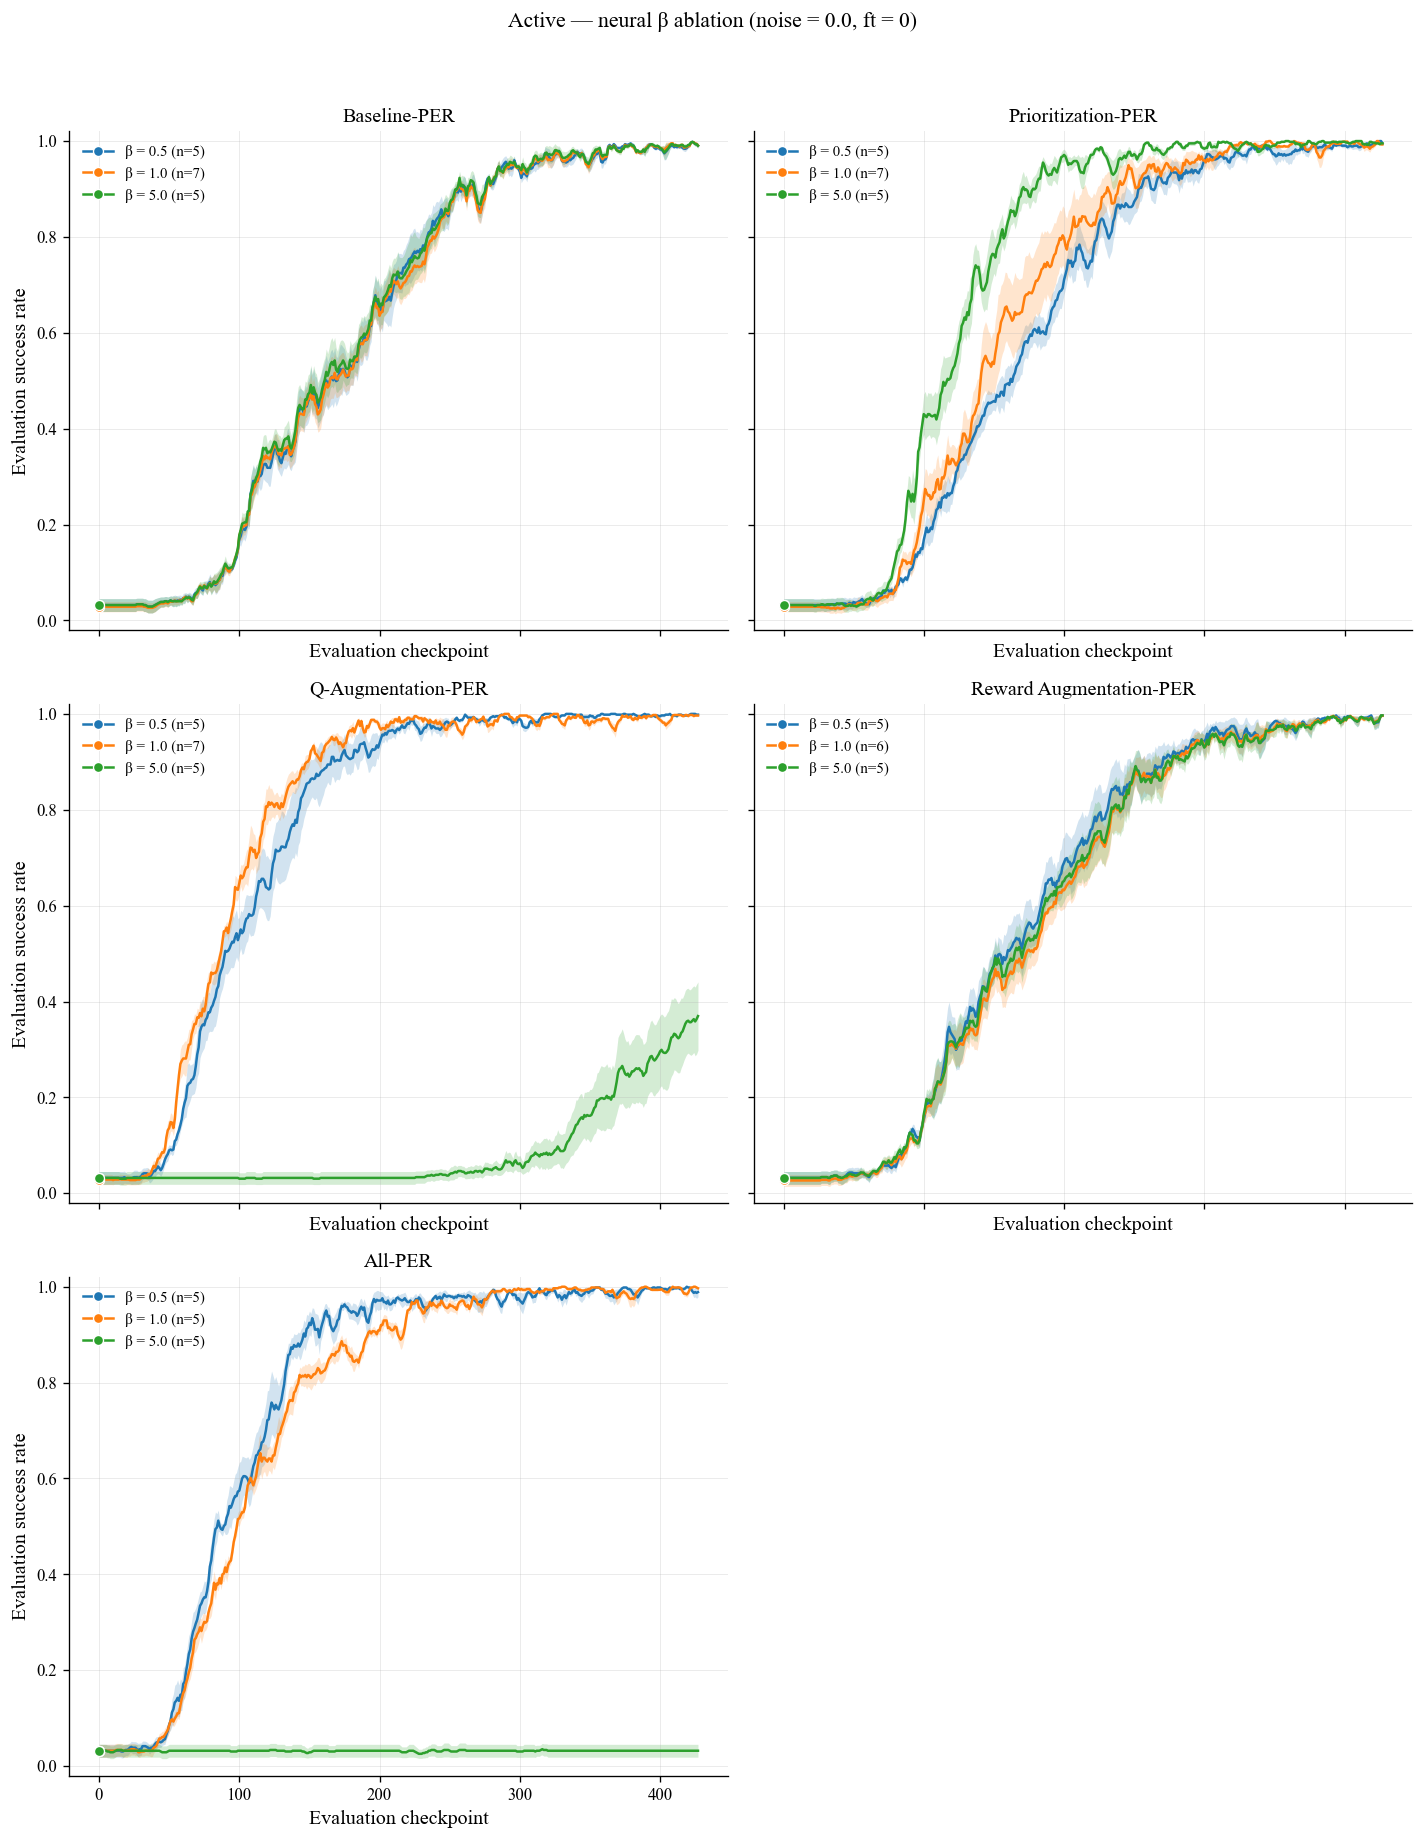

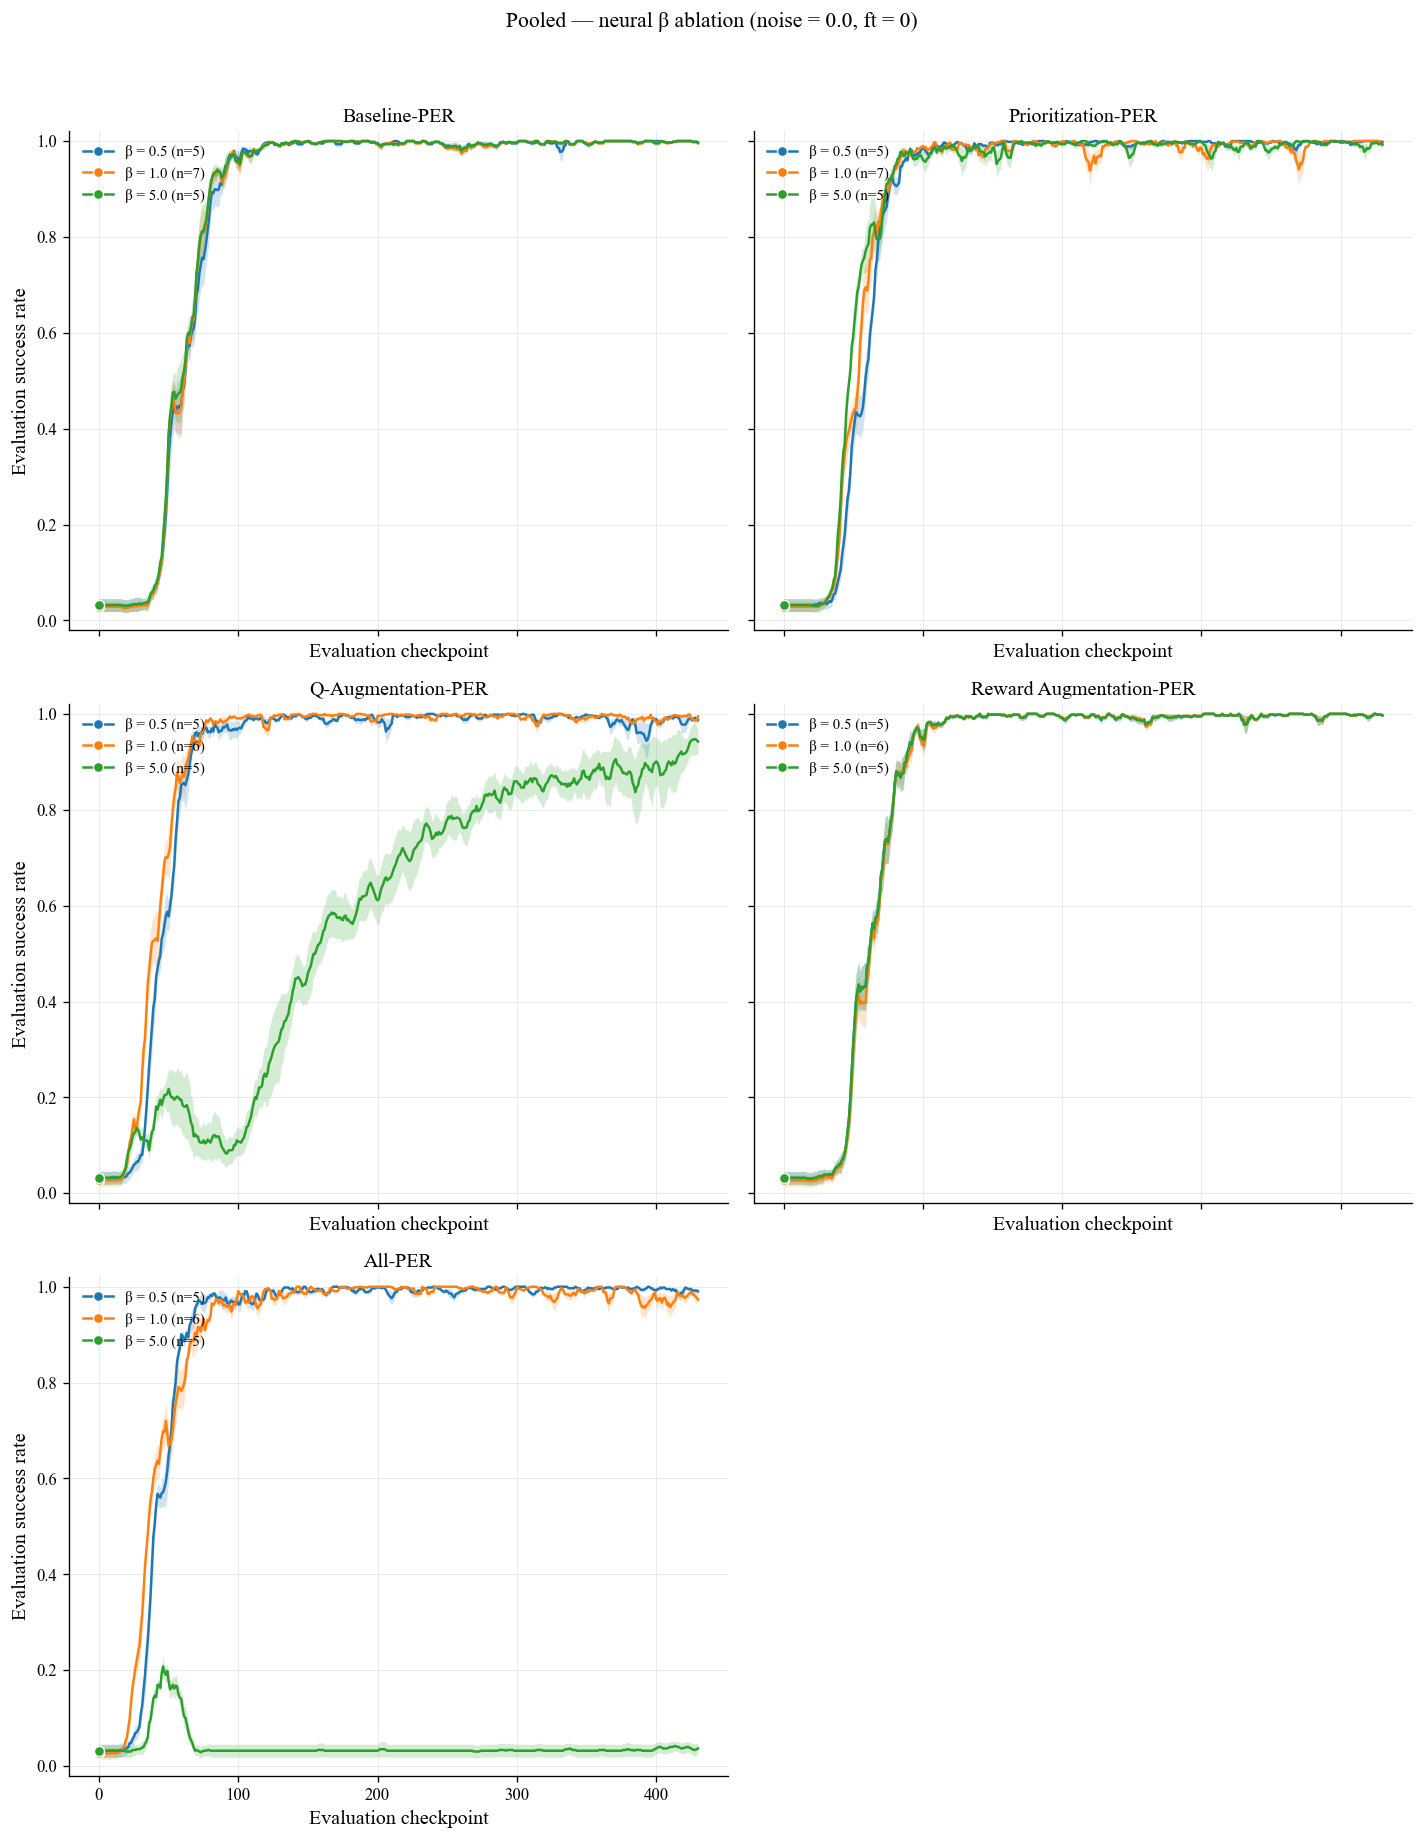

In [37]:
# --- Neural-β ablation: one figure per task ---
# Subplots = neural conditions; lines = β (noise=0, ft=NOISE_BETA_ABLATION_FT)
plot_ablation_for_each_task(
    agg,
    ablation_kind="beta",
    min_lines=1,
    ft=NOISE_BETA_ABLATION_FT,
)


In [38]:
# Summary tables per ablation (condition × level; fixed baselines as in config)
display_ablation_summaries(
    agg,
    ablation_col="ft",
    ablation_order=FT_ORDER,
    fixed={"noise": ABLATION_FT_BASELINE_NOISE, "beta": ABLATION_FT_BASELINE_BETA},
    label="Finetune threshold",
)

display_ablation_summaries(
    agg,
    ablation_col="noise",
    ablation_order=NOISE_ORDER,
    fixed={"beta": ABLATION_NOISE_BASELINE_BETA, "ft": ABLATION_NOISE_BASELINE_FT},
    label="Model noise",
)

display_ablation_summaries(
    agg,
    ablation_col="beta",
    ablation_order=BETA_ORDER,
    fixed={"noise": ABLATION_BETA_BASELINE_NOISE, "ft": ABLATION_BETA_BASELINE_FT},
    label="Neural β",
)


Finetune threshold — curve score per condition (fixed: noise = 0, beta = 1):


ft,0.0,0.2,0.4,0.6,0.8,1.0
condition,,,,,,
Baseline-PER,1.096532,0.470848,NaN,NaN,NaN,NaN
Prioritization-PER,1.095584,0.405798,NaN,NaN,NaN,NaN
Q-Augmentation-PER,1.098953,0.395252,NaN,NaN,NaN,NaN
Reward Augmentation-PER,1.098589,0.434831,NaN,NaN,NaN,NaN
All-PER,1.098439,0.400705,NaN,NaN,NaN,NaN


Peak Evaluation success rate:


ft,0.0,0.2,0.4,0.6,0.8,1.0
condition,,,,,,
Baseline-PER,1.0,1.0,NaN,NaN,NaN,NaN
Prioritization-PER,1.0,1.0,NaN,NaN,NaN,NaN
Q-Augmentation-PER,1.0,1.0,NaN,NaN,NaN,NaN
Reward Augmentation-PER,1.0,1.0,NaN,NaN,NaN,NaN
All-PER,1.0,1.0,NaN,NaN,NaN,NaN


Terminal Evaluation success rate (last 5 checkpoints):


...

beta,0.5,1.0,5.0,10.0
condition,,,,
Baseline-PER,0.800000,0.034615,0.300000,NaN
Prioritization-PER,0.279545,0.800000,0.611688,NaN
Q-Augmentation-PER,0.300000,1.075676,0.301299,NaN
Reward Augmentation-PER,0.800000,0.300000,0.800000,NaN
All-PER,0.705547,1.092315,0.000000,NaN


Peak Evaluation success rate:


beta,0.5,1.0,5.0,10.0
condition,,,,
Baseline-PER,1.0,1.0,1.000,NaN
Prioritization-PER,1.0,1.0,1.000,NaN
Q-Augmentation-PER,1.0,1.0,1.000,NaN
Reward Augmentation-PER,1.0,1.0,1.000,NaN
All-PER,1.0,1.0,0.976,NaN


Terminal Evaluation success rate (last 5 checkpoints):


beta,0.5,1.0,5.0,10.0
condition,,,,
Baseline-PER,0.97984,0.980800,0.98816,NaN
Prioritization-PER,0.99712,0.984000,0.99808,NaN
Q-Augmentation-PER,0.99808,0.995200,0.96256,NaN
Reward Augmentation-PER,0.97984,0.983200,0.97984,NaN
All-PER,0.99424,0.990133,0.92992,NaN


In [39]:
# One figure per finetune_threshold: lines = conditions (alternative view)
def plot_conditions_at_each_ft(table: pd.DataFrame, *, tasks: list | None = None, start_idx: int | None = None, end_idx: int | None = None):
    task_list = tasks if tasks is not None else tasks_to_plot()
    for task in task_list:
        filters = {
            "task": task,
            "noise": ABLATION_FT_BASELINE_NOISE,
            "beta": ABLATION_FT_BASELINE_BETA,
        }
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        ft_present = line_values_present(sub, "ft", FT_ORDER)
        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        if not ft_present or not conditions:
            print(f"Skip {task}: insufficient ft/condition data")
            continue

        publication_figure(
            table,
            title=(
                f"{task} — conditions across finetune thresholds "
                f"(noise = {ABLATION_FT_BASELINE_NOISE}, β = {ABLATION_FT_BASELINE_BETA})"
            ),
            line_col="condition",
            line_values=conditions,
            subplot_col="ft",
            subplot_values=ft_present,
            filters=filters,
            filename=f"conditions_by_ft__{slugify(task)}.pdf",
            start_idx=start_idx,
            end_idx=end_idx,
        )


# Uncomment to plot the alternative layout:
# plot_conditions_at_each_ft(agg)


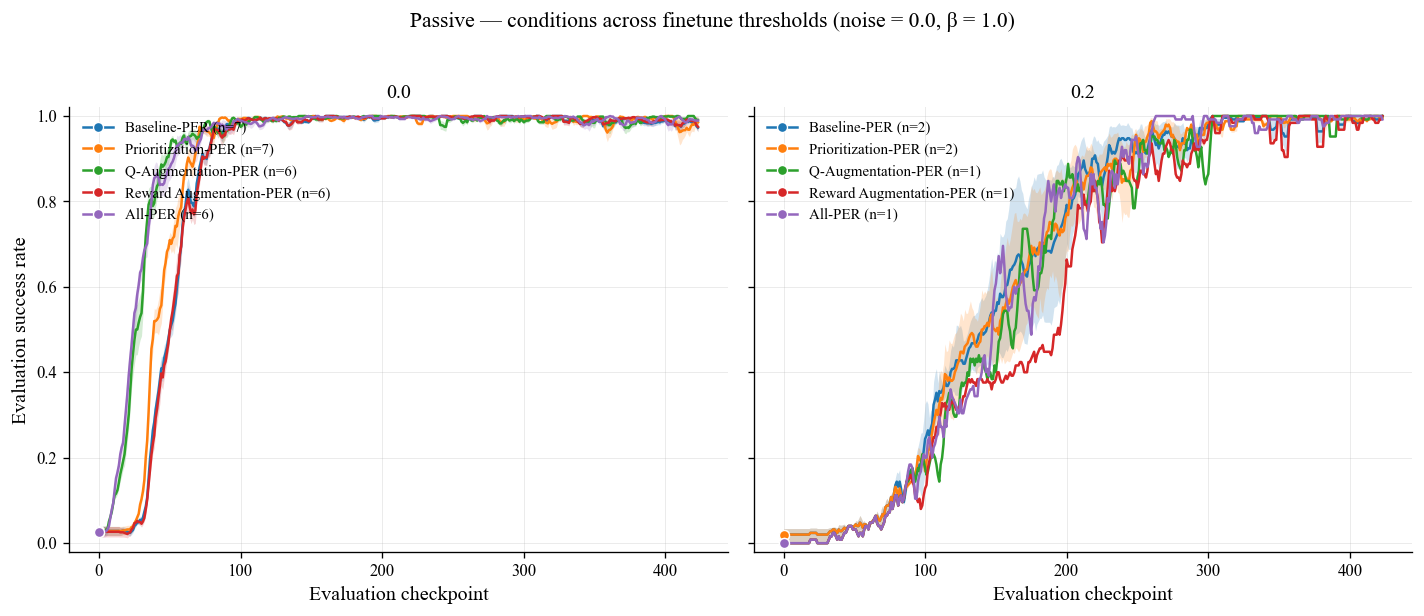

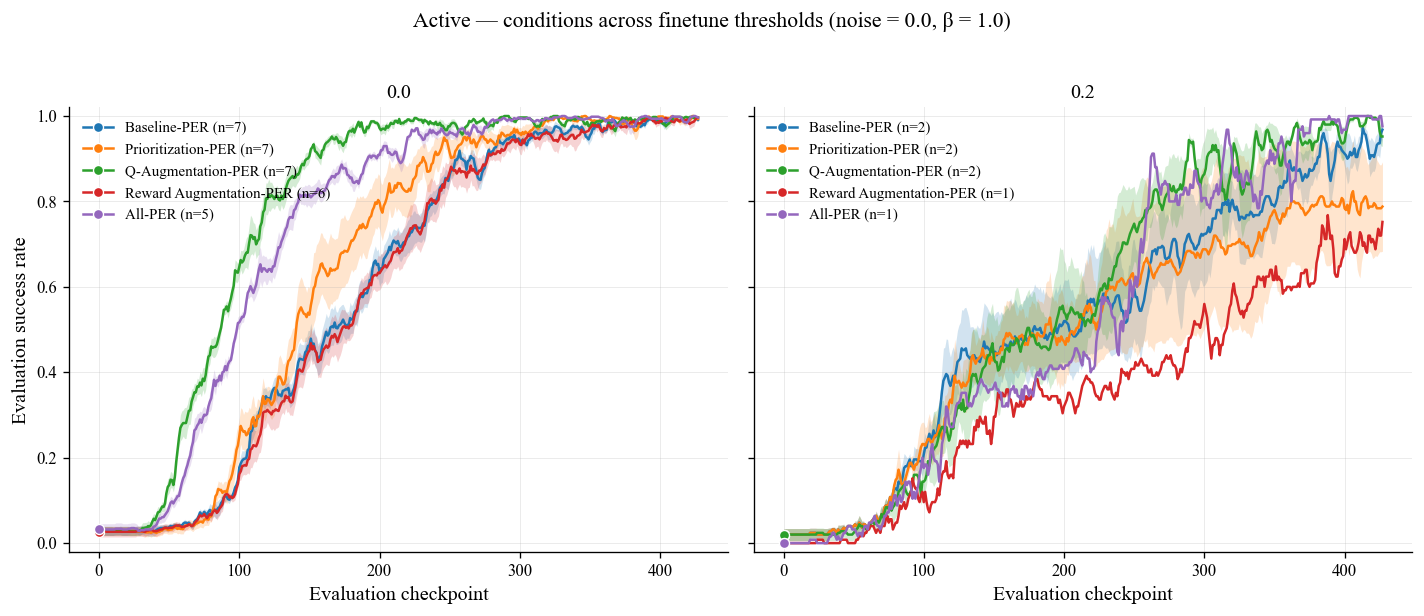

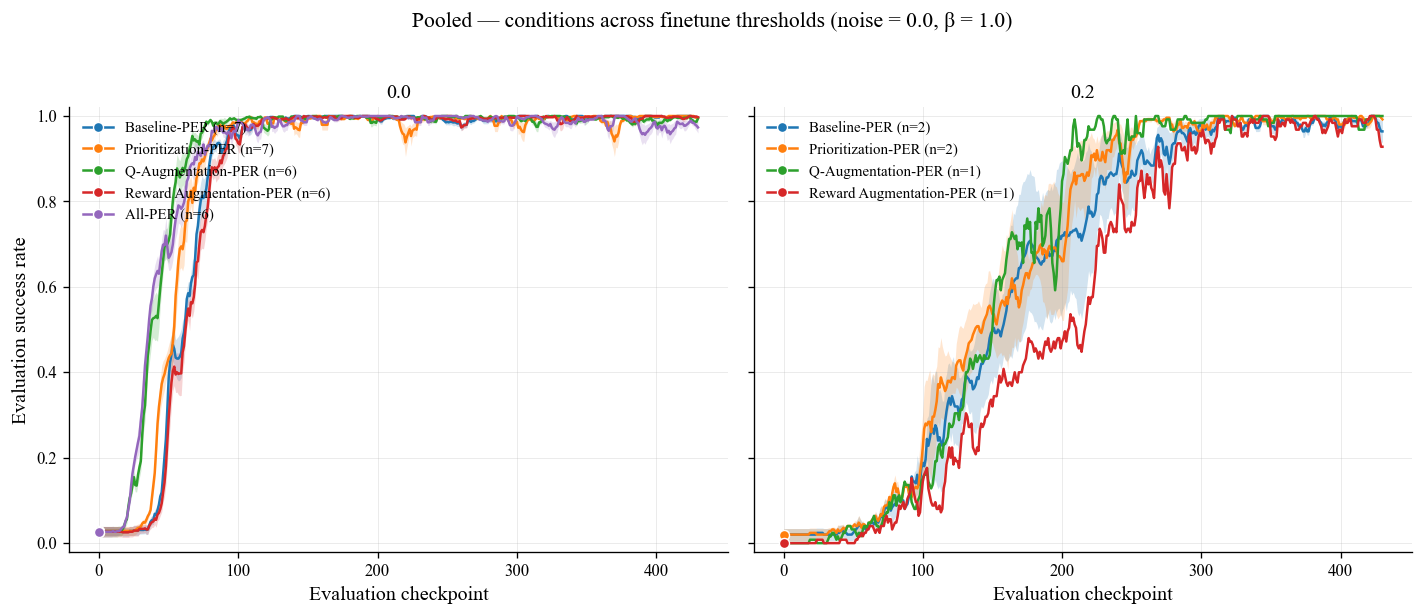

In [40]:
# Uncomment to plot the alternative layout:
plot_conditions_at_each_ft(agg)

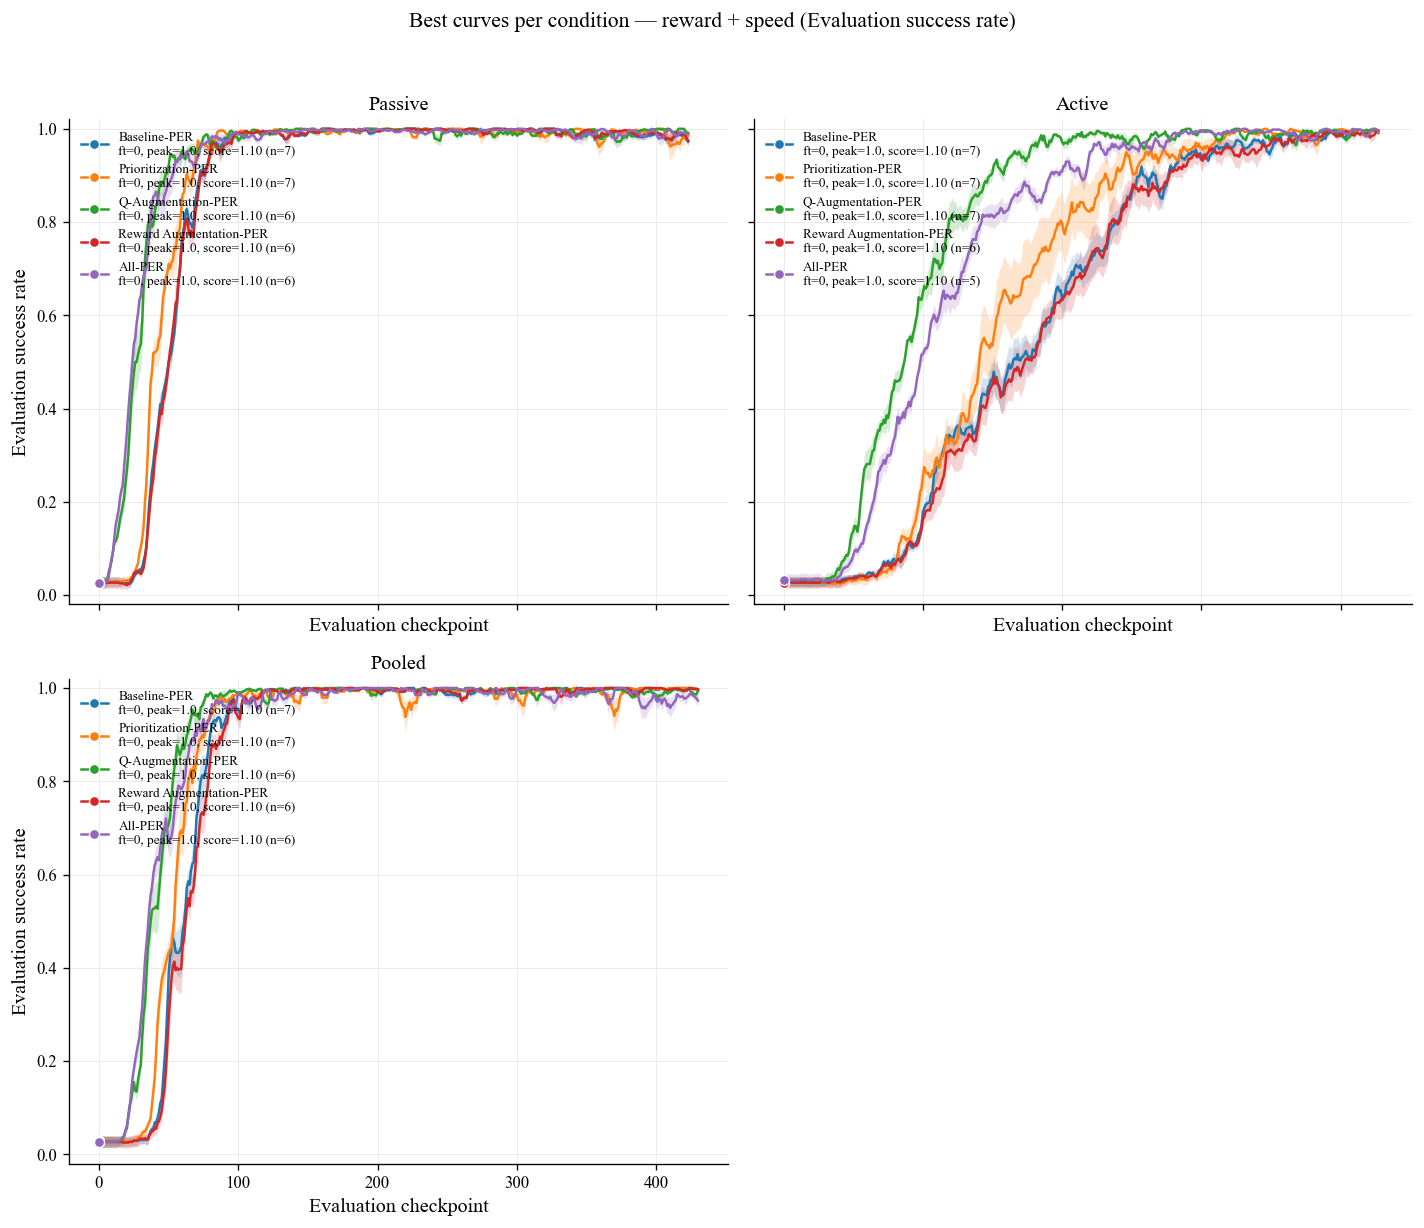

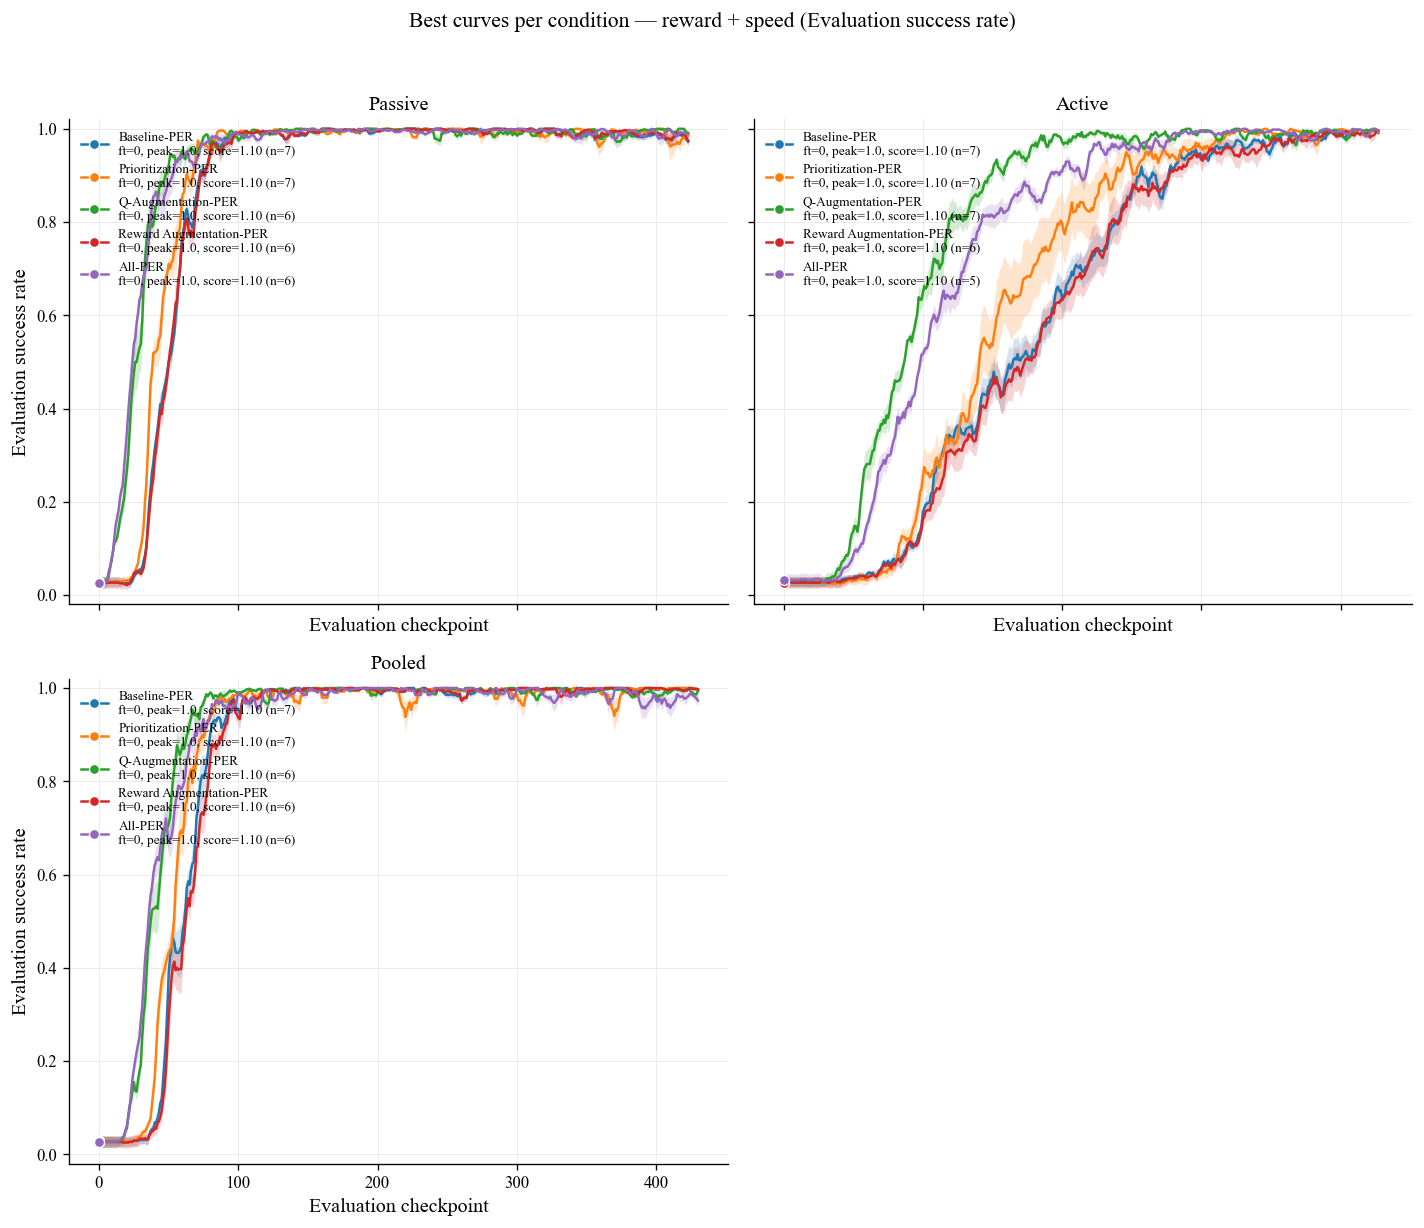

In [41]:
# Optional: best (noise, β, ft) per task × condition summary figure
plot_conditions_best_per_task_condition(agg, filters=FT_BEST_FILTERS)